# Seasonality in transmission

Let's look at seasonal transmission in the SIR model.

To open an interactive version of this notebook, click [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/laser-base/laser-generic/HEAD?urlpath=lab%2Ftree%2Fdocs%2Ftutorials%2Fnotebooks%2Fseasonality.ipynb). Note that it may take a few minutes to create the environment and edits will not be saved.

In [ ]:
import numpy as np

from laser.core.utils import grid
from laser.core import PropertySet
import laser.core.distributions as dists

from laser.generic import Model
from laser.generic import SI
from laser.generic import SIR
from laser.generic import SEIR
from laser.generic.vitaldynamics import ConstantPopVitalDynamics
from laser.generic.utils import ValuesMap

import os

if "BINDER_REPO_URL" in os.environ:
    # Binder containers report the host's full core count via os.cpu_count(), which numba's
    # parallel=True kernels (used inside laser.core/laser.generic) use to size their thread pool -
    # but Binder only grants a small CPU quota, so that pool oversubscribes it and thrashes.
    # Local runs and the docs build see an accurate core count, so they're unaffected and keep
    # numba's default thread count.
    import numba

    numba.set_num_threads(1)

## Baseline - no seasonality

First, let's run a model with no seasonal forcing of transmission. Transmission is always driven by $\beta$ with no temporal or spatial variation.

The shortcut for this is to omit the `seasonality` parameter to the `Transmission` component or explicitly set it to `None`. The `Transmission` component will use 1.0 at all times in this case.


In [ ]:
NTICKS = 365 * 10
infectious_duration_mean = 14.0
infectious_duration_scale = 1.5
R0 = 15.0
beta = R0 / infectious_duration_mean
CBR = 33
mu = (1 + (CBR / 1000))**(1/365) - 1

scenario = grid(1, 1, population_fn=lambda row, col: 1_000_000)
scenario["S"] = np.round(scenario.population / R0).astype(np.int32)
scenario["I"] = (scenario.population * mu * (R0 - 1) / beta).astype(np.int32)
scenario["R"] = scenario.population - (scenario.S + scenario.I)

parameters = PropertySet({"nticks": NTICKS, "beta": beta})

no_seasonality = Model(scenario, parameters, birthrates=None)

infdurdist = dists.normal(loc=infectious_duration_mean, scale=infectious_duration_scale)

no_seasonality.components = [
    SIR.Susceptible(no_seasonality),
    SIR.Infectious(no_seasonality, infdurdist, infdurmin=1.0),
    SIR.Recovered(no_seasonality),
    SIR.Transmission(no_seasonality, infdurdist, infdurmin=1.0, seasonality=None),
    ConstantPopVitalDynamics(no_seasonality, recycle_rates=ValuesMap.from_scalar(CBR, NTICKS, 1)),
]

no_seasonality.run()

### Baseline results

Let's plot the S, I, and R traces for the baseline scenario. Even without seasonal forcing we see a natural periodicity.


In [ ]:
import matplotlib.pyplot as plt

def plot_model(model, caption=None):
    history = model.nodes

    _fig, ax1 = plt.subplots(figsize=(10, 6))

    styles = ['-', '--', '-.', ':']

    # Primary axis: S and R
    for node in range(model.nodes.count):
        ax1.plot(history.S[:, node], label=f'Susceptible (S) - Node {node}', color='tab:blue', linestyle=styles[node % len(styles)])
        ax1.plot(history.R[:, node], label=f'Recovered (R) - Node {node}', color='tab:green', linestyle=styles[node % len(styles)])
    ax1.set_xlabel('Time (days)')
    ax1.set_ylabel('Population (S, R)')

    N = (history.S + history.I + history.R)
    ax1.set_ylim(-N.max() / 10, N.max())

    ax1.legend(loc='upper left')
    ax1.grid()

    # Secondary axis: I
    ax2 = ax1.twinx()
    for node in range(model.nodes.count):
        ax2.plot(history.I[:, node], label=f'Infectious (I) - Node {node}', color='tab:red', linestyle=styles[node % len(styles)])
    ax2.set_ylabel('Population (I)')

    maximum = ((int(history.I.max()) // 500) + 1) * 500
    ax2.set_ylim(-maximum / 10, maximum)

    # If there is a seasonal component, plot it overlaid on ax2
    transmission = next((comp for comp in model.components if isinstance(comp, (SI.Transmission, SIR.Transmission, SEIR.Transmission))), None)
    if transmission and hasattr(transmission, 'seasonality'):
        seasonality = transmission.seasonality.values
        scaled = seasonality * maximum / 2
        for node in range(model.nodes.count):
            ax2.plot(scaled[:,node], label='Seasonality (scaled)', color='tab:gray', linestyle=styles[node % len(styles)], alpha=0.5)

    ax2.legend(loc='upper right')

    plt.title('SIR Model: S, I, and R over Time')
    if caption:
        plt.figtext(0.5, -0.05, caption, ha="center", va="top", wrap=True, fontsize=8)
    plt.show()

plot_model(no_seasonality, caption='The plot demonstrates that even without seasonal forcing, an SIR model with births produces damped, irregular endemic oscillations — the natural baseline that subsequent seasonal-forcing experiments must be compared against.')

## Seasonality

Let's introduce some seasonal forcing on a yearly basis: $1 + 0.2 * sin((t - 214)/365)$ where `t = tick % 365`.

We will offset `t` by 214 to anchor the increase in transmission around the start of school.


In [ ]:
sinusoidal = Model(scenario, parameters, birthrates=None)

# We will use a seasonal factor +/- 20% around a mean of 1.0 anchored to day 214 (beginning of school)
seasonality = ValuesMap.from_timeseries(
    1.0 + 0.2 * np.sin((np.arange(NTICKS) - 214) * (2 * np.pi / 365)),
    sinusoidal.nodes.count,
)

sinusoidal.components = [
    SIR.Susceptible(sinusoidal),
    SIR.Infectious(sinusoidal, infdurdist, infdurmin=1.0),
    SIR.Recovered(sinusoidal),
    SIR.Transmission(sinusoidal, infdurdist, infdurmin=1.0, seasonality=seasonality),
    ConstantPopVitalDynamics(sinusoidal, recycle_rates=ValuesMap.from_scalar(CBR, NTICKS, 1)),
]

sinusoidal.run()


### Seasonality results

Interestingly, with the annual forcing we see the start of more regular outbreaks before a low point in transmission leads to local elimination. Note the magnitude of the outbreaks is quite a bit higher than the baseline scenario.


In [ ]:
plot_model(sinusoidal, caption='The plot demonstrates that seasonal forcing of $\\beta(t)$ synchronizes outbreaks into larger, sharper annual peaks, but in a closed population the deeper troughs drive the infection extinct — motivating the importation experiment that follows.')



## Importation

Looks like we are going to need some periodic importation to keep from seeing extinction.

In [ ]:
from laser.generic import State

class Importation:
    def __init__(self, model, period, cases, infdurdist, infdurmin=1.0):
        self.model = model
        self.period = period
        self.cases = cases
        self.infdurdist = infdurdist
        self.infdurmin = infdurmin

        return

    def step(self, tick):
        if tick % self.period != 0:
            return

        susceptible_indices = np.nonzero(self.model.people.state == State.SUSCEPTIBLE.value)[0]
        imports = np.random.choice(susceptible_indices, size=self.cases, replace=False)
        self.model.people.state[imports] = State.INFECTIOUS.value
        self.model.people.itimer[imports] = np.maximum(np.round(dists.sample_floats(self.infdurdist, np.zeros_like(imports, dtype=np.float32), 0, 0)), self.infdurmin)

        # print(f"Importing {len(imports):3} cases at tick {tick:4}")

        self.model.nodes.S[tick+1] -= len(imports)
        self.model.nodes.I[tick+1] += len(imports)

        return

In [ ]:
with_importation = Model(scenario, parameters, birthrates=None)

with_importation.components = [
    SIR.Susceptible(with_importation),
    SIR.Infectious(with_importation, infdurdist, infdurmin=1.0),
    SIR.Recovered(with_importation),
    SIR.Transmission(with_importation, infdurdist, infdurmin=1.0, seasonality=seasonality),
    ConstantPopVitalDynamics(with_importation, recycle_rates=ValuesMap.from_scalar(CBR, NTICKS, 1)),
    Importation(with_importation, period=30, cases=3, infdurdist=infdurdist, infdurmin=1.0),
]

with_importation.run()

## Seasonality with importation

Now we see outbreaks even higher but sharper as outbreaks synchronize with the seasonal forcing and transmission is attenuated shortly after the outbreak peak. Note the timing of the outbreaks after day 1500 and their alignment with the seasonality factor.

In [ ]:
plot_model(with_importation, caption='The plot demonstrates that constant low-rate importation (3 cases every 30 days) is enough to break the fadeout problem and let seasonal forcing entrain a stable biennial outbreak cycle phase-locked to the annual $\\beta(t)$ peak.')



So, a few cases coming in every 30 days along with seasonal forcing gives us a very nice periodic outbreak every two years.

It might be interesting to see how seasonal forcing interacts with critical community size for endemicity. We will leave that as an exercise for the reader.


## Coupled locations with out of phase seasonality

Out of curiosity, let's use spatial heterogeneity and build a two node model where the seasonality factors are out of phase between the two nodes.

In [ ]:
## Coupled locations with out of phase seasonality.

two_node_scenario = grid(1, 2, population_fn=lambda row, col: 500_000)
two_node_scenario["S"] = np.round(two_node_scenario.population / R0).astype(np.int32)
two_node_scenario["I"] = (two_node_scenario.population * mu * (R0 - 1) / beta).astype(np.int32)
two_node_scenario["R"] = two_node_scenario.population - (two_node_scenario.S + two_node_scenario.I)

two_node_model = Model(two_node_scenario, parameters, birthrates=None)

two_node_seasonality = np.zeros((NTICKS, two_node_model.nodes.count), np.float32)
two_node_seasonality[:, 0] = 1.0 + 0.2 * np.sin((np.arange(NTICKS) - 214) * (2 * np.pi / 365))
two_node_seasonality[:, 1] = 1.0 + 0.2 * np.sin((np.arange(NTICKS) - 214 + 183) * (2 * np.pi / 365))

two_node_model.components = [
    SIR.Susceptible(two_node_model),
    SIR.Infectious(two_node_model, infdurdist, infdurmin=1.0),
    SIR.Recovered(two_node_model),
    SIR.Transmission(two_node_model, infdurdist, infdurmin=1.0, seasonality=ValuesMap.from_array(two_node_seasonality)),
    ConstantPopVitalDynamics(two_node_model, recycle_rates=ValuesMap.from_scalar(CBR, NTICKS, 1)),
    Importation(two_node_model, period=365, cases=3, infdurdist=infdurdist, infdurmin=1.0),
]

two_node_model.network /= 500.0  # Reduce coupling for clearer dynamics.

two_node_model.run()


## Two node out of phase model

Interesting results. The second node, out of phase, provides a reservoir of infection which causes smaller outbreaks between the peaks we saw in the previous model. Also, the magnitude of the outbreaks in the primary node is quite a bit smaller.

In [ ]:
plot_model(two_node_model, caption='The plot demonstrates that spatial coupling between out-of-phase seasonal patches produces richer inter-epidemic dynamics — a quieter "reservoir" node sustains transmission during the primary node\'s seasonal trough, filling in smaller off-cycle outbreaks and damping the peak amplitudes seen in the single-node case.')



Note: Our two model network transfers ~0.02% of local contagion to the other node on each timestep.

In [ ]:
two_node_model.network


## Test the SI model

Let's a) make sure the TransmissionSIx component's seasonality is working and b) let's use a crazy "seasonality" to make the effect obvious.

Again, let's start with a baseline of no seasonality.


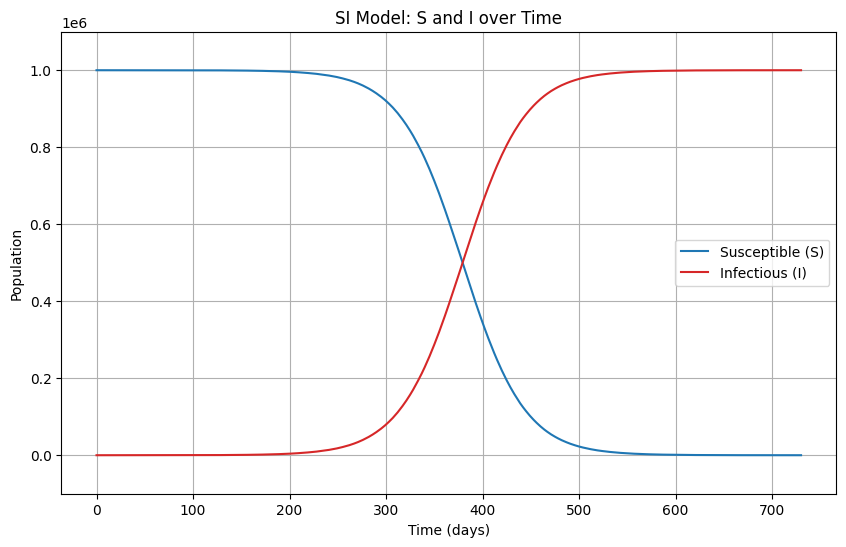

In [ ]:
from laser.generic import SI

scenario = grid(1, 1, population_fn=lambda row, col: 1_000_000)
scenario["S"] = scenario.population - 10
scenario["I"] = 10

# 1, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625
parameters = PropertySet({"nticks": 730, "beta": 0.03125})

si_wout_seasonality = Model(scenario, parameters, birthrates=None)
si_wout_seasonality.components = [
    SI.Susceptible(si_wout_seasonality),
    SI.Infectious(si_wout_seasonality),
    SI.Transmission(si_wout_seasonality, seasonality=None),
]

si_wout_seasonality.run("SI model without seasonality")

def plot_si_model(model, caption=None):
    history = model.nodes

    plt.figure(figsize=(10, 6))
    plt.plot(history.S[:, 0], label='Susceptible (S)', color='tab:blue')
    plt.plot(history.I[:, 0], label='Infectious (I)', color='tab:red')
    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title('SI Model: S and I over Time')
    plt.ylim(-model.scenario.population[0] / 10, model.scenario.population[0] * 1.1)
    plt.legend()
    plt.grid()
    if caption:
        plt.figtext(0.5, -0.05, caption, ha="center", va="top", wrap=True, fontsize=8)
    plt.show()

    return

plot_si_model(si_wout_seasonality, caption='The plot demonstrates the canonical undriven SI take-off-and-saturate curve at the chosen $\\beta$ — the control trajectory against which the next cell\'s "radical seasonality" (an intervention applied between days 300 and 400) will be compared.')


## Radical "seasonality"

Now, let's set up "seasonality" which attenuates transmission from 100% to 0% over the course of 100 days. We can imagine that this is a hypothetical intervention that is triggered shortly after detection of the outbreak.

Note this scenario demonstrates that the spatio-temporal "seasonality" factor does not have to be cyclical and can be used to model the effects of interventions.


In [ ]:
si_with_seasonality = Model(scenario, parameters, birthrates=None)

seasonality = np.ones((parameters.nticks, si_with_seasonality.nodes.count), np.float32)
# Phase out transmission between days 300 and 400
seasonality[300:400,:] = np.linspace(1.0, 0.0, 100)[:, None]
seasonality[400:,:] = 0.0
seasonality = ValuesMap.from_array(seasonality)

si_with_seasonality.components = [
    SI.Susceptible(si_with_seasonality),
    SI.Infectious(si_with_seasonality),
    SI.Transmission(si_with_seasonality, seasonality=seasonality),
]

si_with_seasonality.run("SI model with seasonality")


## SI with "seasonality"

We see that the effect of our hypothetical intervention is to initially attenuate and then halt the outbreak.

In [ ]:
plot_si_model(si_with_seasonality, caption='The plot demonstrates that the seasonality input is general-purpose temporal modulation of $\\beta(t)$ — not restricted to cyclical forcing — and can be used to model the population-level effect of a time-limited intervention that arrests an outbreak partway through its logistic take-off.')

